<a href="https://colab.research.google.com/github/SATHIYAPRIYA-27/Calculator/blob/main/StoreSales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving holidays_events.csv to holidays_events.csv
Saving oil.csv to oil.csv
Saving sample_submission.csv to sample_submission.csv
Saving stores.csv to stores.csv
Saving test.csv to test.csv
Saving train.csv to train.csv
Saving transactions.csv to transactions.csv


In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
from xgboost import XGBRegressor

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

stores = pd.read_csv("stores.csv")
oil = pd.read_csv("oil.csv")
holidays = pd.read_csv("holidays_events.csv")
transactions = pd.read_csv("transactions.csv")

In [ ]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [ ]:
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

In [ ]:
for df in [train, test]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek

In [ ]:
train["family"] = train["family"].astype("category").cat.codes
test["family"] = test["family"].astype("category").cat.codes

In [ ]:
train_sample = train.sample(n=200000, random_state=42)

In [ ]:
X = train_sample[[
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "day",
    "dayofweek"
]]

y = train_sample["sales"]

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_valid.shape)

(160000, 7)
(40000, 7)


In [ ]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    objective="reg:squarederror",
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred = model.predict(X_valid)

In [ ]:
score = np.sqrt(
    mean_squared_log_error(
        y_valid,
        np.maximum(pred, 0)
    )
)

print("Validation RMSLE:", score)

Validation RMSLE: 1.6957490563131907


In [ ]:
model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
X_test = test[[
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "day",
    "dayofweek"
]]

In [ ]:
test_predictions = model.predict(X_test)

In [ ]:
submission = pd.DataFrame({
    "id": test["id"],
    "sales": test_predictions
})

submission.head()

,id,sales
0,3000888,11.425021
1,3000889,8.917603
2,3000890,81.901085
3,3000891,2027.152222
4,3000892,22.094425


In [ ]:
submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")

Submission file created successfully!


In [ ]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

       Feature  Importance
2  onpromotion    0.316806
1       family    0.276781
0    store_nbr    0.164738
3         year    0.108129
6    dayofweek    0.079048
4        month    0.029806
5          day    0.024693


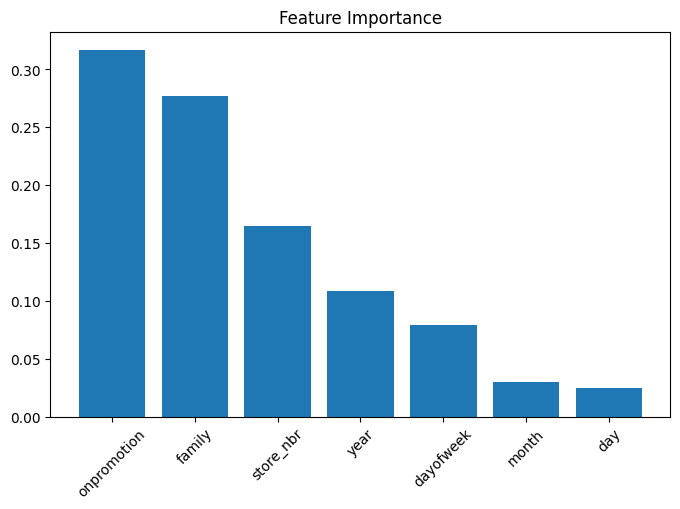

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [ ]:
print("Validation RMSLE:", score)

Validation RMSLE: 1.6957490563131907
